<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/flow_matching_checkerboard_ECI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [1]:
!pip install torchcfm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 36.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 72.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 76.0 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher
import matplotlib.pyplot as plt
import numpy as np
from tqdm.auto import tqdm

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# Dataset

In [4]:
def get_checkerboard_data(n_samples, board_size):
    valid_indices = [
        (i, j)
        for i in range(board_size)
        for j in range(board_size)
        if (i + j) % 2 == 0
    ]

    n_squares = len(valid_indices)
    points_per_square = n_samples // n_squares

    data = []
    for i, j in valid_indices:
        x = np.random.uniform(i, i+1, points_per_square)
        y = np.random.uniform(j, j+1, points_per_square)
        data.append(np.stack([x, y], axis=1))

    data = np.concatenate(data, axis=0)
    data -= board_size / 2

    return torch.from_numpy(data).float()

In [5]:
data = get_checkerboard_data(n_samples=10000, board_size=4)

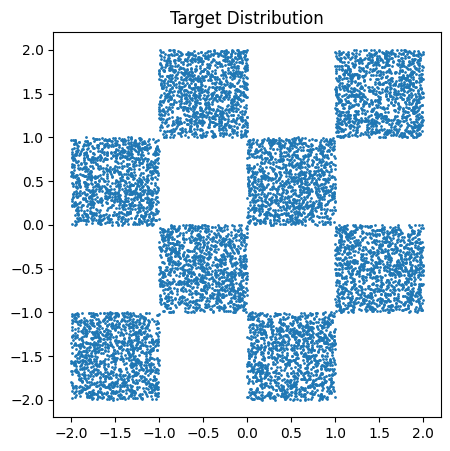

In [6]:
plt.figure(figsize=(5, 5))
plt.scatter(data[:, 0], data[:, 1], s=1)
plt.title("Target Distribution")
plt.show()

# Model definition

In [7]:
class VectorFieldNetwork(nn.Module):
    def __init__(self, board_size, input_dim=3, hidden_dim=128, output_dim=2):
        # input_dim=3 for x, y location and t as time
        # output_dim=2 for the predicted 2d vector
        super().__init__()
        self.board_size = board_size
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, t, x):
        # t - the current timestamp - a number between 0 and 1 (size [batch]).
        # x - the locations x, y of the points (size [batch, 2])
        x_norm = x / (self.board_size / 2)  # scaling locations down to [-1, 1] for stability
        t = t.unsqueeze(1)  # converting to size [batch, 1]
        x_t = torch.cat([x, t], dim=1)
        return self.mlp(x_t)  # resulting v doesn't have to be scaled back up

# Train loop

In [8]:
# Settings
board_size = 4
model = VectorFieldNetwork(board_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=0.0)
iterations = 50000
batch_size = 256

loss_list = []

In [9]:
for step in tqdm(range(iterations)):
    optimizer.zero_grad()

    x1 = get_checkerboard_data(n_samples=batch_size, board_size=board_size).to(device)  # real data
    x0 = torch.randn_like(x1).to(device)  # noise

    # compute loss
    t, xt, real_vt = FM.sample_location_and_conditional_flow(x0, x1)
    pred_vt = model(t, xt)
    loss = torch.mean((pred_vt - real_vt) ** 2)
    loss_list.append(loss.item())
    if step % (iterations / 10) == 0:
        print(np.mean(loss_list[step - int(iterations/10):step+1]))

    loss.backward()
    optimizer.step()

  0%|          | 0/50000 [00:00<?, ?it/s]

0.14299419522285461
0.0423314095469379
0.03464554325215424
0.03372366325972593
0.033426652214951905
0.033141830482424625
0.033013161416695344
0.032955056521575994
0.032899206455434184
0.032652259255496655


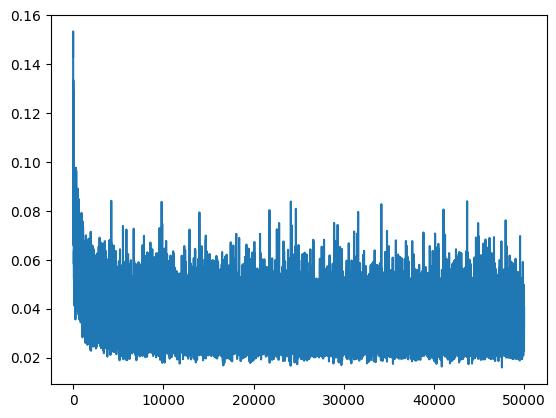

In [10]:
plt.plot(loss_list)
plt.show()

# Data sampler

In [11]:
def sample_trajectory(model, n_samples, steps=100):
    x = torch.randn(n_samples, 2).to(device)  # x0 - noise
    dt = 1.0 / steps

    traj = [x.clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((x.shape[0],), t).to(device)
            v = model(t_batch, x)
            x = x + v * dt

            traj.append(x.clone().cpu())

    return torch.stack(traj).numpy()  # [steps, n_samples, 2]

In [12]:
sampled_data = sample_trajectory(model, n_samples=5000)

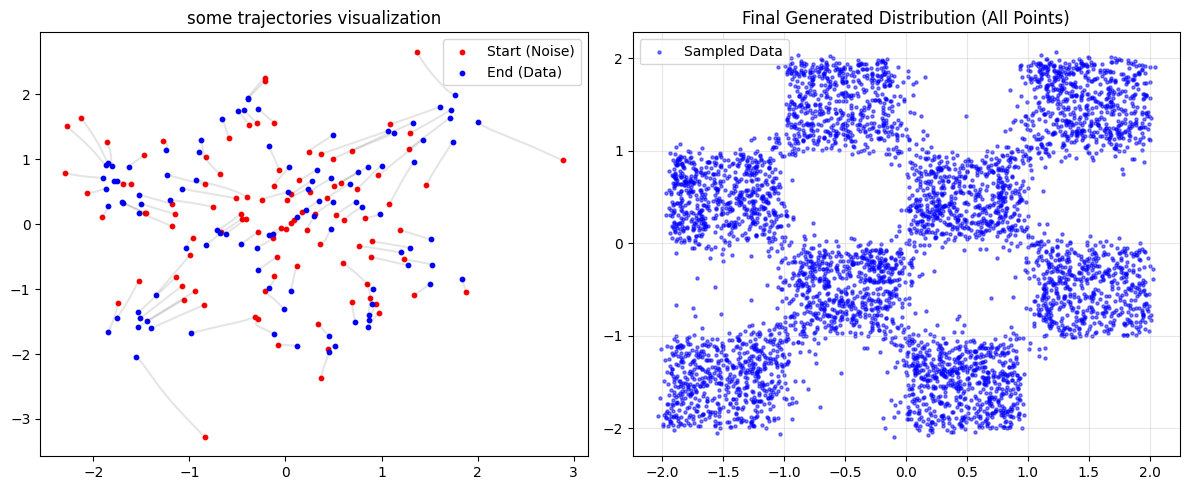

In [13]:
start_points = sampled_data[0]  # t=0
end_points = sampled_data[-1]  # t=1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Flow plot
axes[0].set_title("some trajectories visualization")
for i in range(100):
    xs = sampled_data[:, i, 0]
    ys = sampled_data[:, i, 1]
    axes[0].plot(xs, ys, color='black', alpha=0.1)  # plotting the trajectory lines

axes[0].scatter(start_points[:100, 0], start_points[:100, 1], c='red', s=10, label='Start (Noise)')
axes[0].scatter(end_points[:100, 0], end_points[:100, 1], c='blue', s=10, label='End (Data)')
axes[0].legend()

# Final Distribution
axes[1].set_title("Final Generated Distribution (All Points)")
# correct_pattern = get_checkerboard_data(n_samples=1000, board_size=board_size)
# axes[1].scatter(correct_pattern[:, 0], correct_pattern[:, 1], s=5, color='magenta', alpha=0.5, label="Correct Pattern")
axes[1].scatter(end_points[:, 0], end_points[:, 1], s=5, color='blue', alpha=0.5, label="Sampled Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Data sampler - ECI

In [18]:
def sample_trajectory_eci(model, n_samples, constraint_fn, steps=100, correction_loops=1):
    model.eval()
    x = torch.randn(n_samples, 2).to(device)  # x0 - noise
    x0 = x.clone()
    dt = 1.0 / steps

    traj = [x.clone().cpu()]
    with torch.no_grad():
        for i in range(steps):
            t = i * dt
            t_batch = torch.full((x.shape[0],), t).to(device)
            for m in range(correction_loops):  # applying the eci projections m times every step
                # Extrapolation
                v = model(t_batch, x)
                x1_pred = x + (1 - t) * v

                # Correction
                x1_corrected = constraint_fn(x1_pred)

                # Interpolation
                x_new = (1 - t) * x0 + t * x1_corrected
                if m < correction_loops - 1:
                    x = x_new

            next_t = t + dt
            x = (1 - next_t) * x0 + next_t * x1_corrected
            traj.append(x.clone().cpu())

    return torch.stack(traj).numpy()  # [steps, n_samples, 2]

In [23]:
def valid_squares_constraint(x1_pred, epsilon=0.001):
    x1_fixed = x1_pred.clone()

    x_floor = torch.floor(x1_fixed[:, 0])
    y_floor = torch.floor(x1_fixed[:, 1])

    x_frac = x1_fixed[:, 0] - x_floor
    y_frac = x1_fixed[:, 1] - y_floor

    sum_idx = x_floor + y_floor
    is_invalid = ((x_floor + y_floor) % 2 != 0)

    mask_top = is_invalid & (y_frac > x_frac) & (y_frac > (1 - x_frac))
    mask_bottom = is_invalid & (y_frac < x_frac) & (y_frac < (1 - x_frac))
    mask_right = is_invalid & (y_frac < x_frac) & (y_frac > (1 - x_frac))
    mask_left = is_invalid & (y_frac > x_frac) & (y_frac < (1 - x_frac))

    # Shift Up (y + 1)
    x1_fixed[mask_top, 1] = y_floor[mask_top] + 1.0 + epsilon

    # Shift Down (y - 1)
    x1_fixed[mask_bottom, 1] = y_floor[mask_bottom] - epsilon

    # Shift Right (x + 1)
    x1_fixed[mask_right, 0] = x_floor[mask_right] + 1.0 + epsilon

    # Shift Left (x - 1)
    x1_fixed[mask_left, 0] = x_floor[mask_left] - epsilon

    return x1_fixed

In [24]:
sampled_data = sample_trajectory_eci(model, n_samples=5000, constraint_fn=valid_squares_constraint, correction_loops=5)

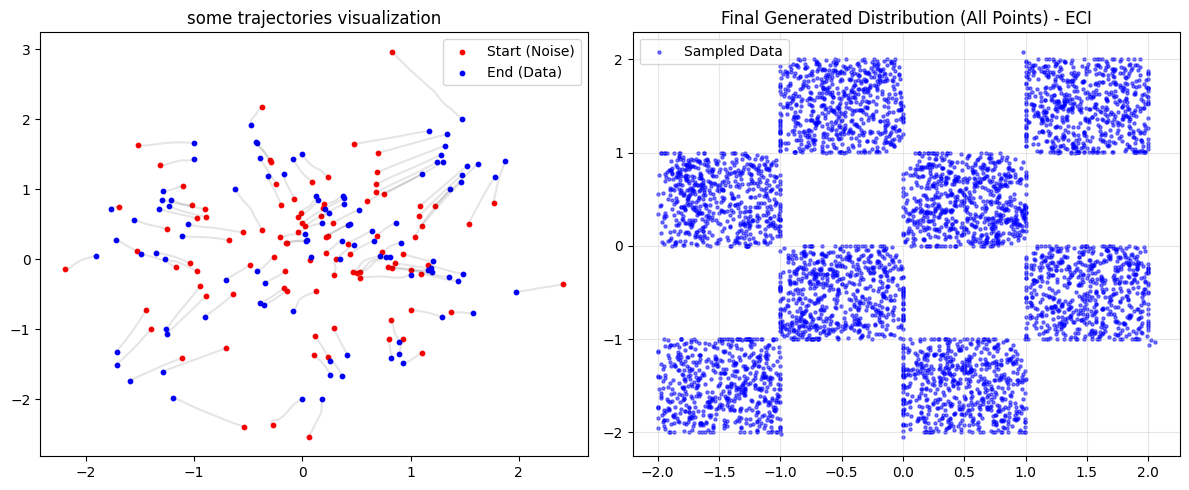

In [26]:
start_points = sampled_data[0]  # t=0
end_points = sampled_data[-1]  # t=1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Flow plot
axes[0].set_title("some trajectories visualization")
for i in range(100):
    xs = sampled_data[:, i, 0]
    ys = sampled_data[:, i, 1]
    axes[0].plot(xs, ys, color='black', alpha=0.1)  # plotting the trajectory lines

axes[0].scatter(start_points[:100, 0], start_points[:100, 1], c='red', s=10, label='Start (Noise)')
axes[0].scatter(end_points[:100, 0], end_points[:100, 1], c='blue', s=10, label='End (Data)')
axes[0].legend()

# Final Distribution
axes[1].set_title("Final Generated Distribution (All Points) - ECI")
# correct_pattern = get_checkerboard_data(n_samples=1000, board_size=board_size)
# axes[1].scatter(correct_pattern[:, 0], correct_pattern[:, 1], s=5, color='magenta', alpha=0.5, label="Correct Pattern")
axes[1].scatter(end_points[:, 0], end_points[:, 1], s=5, color='blue', alpha=0.5, label="Sampled Data")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()